# Model creation 

This notebook will include the building of my model, from the tokenization to the attention encoder-decoder. 

## Load requirements

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Setup complete!")

PyTorch version: 2.10.0
Setup complete!


## Load preprocessed dataset

In [ ]:
dataset = torch.load("../data/MNIST/multi_mnist.pt")

images = dataset["images"]
labels = dataset["labels"]

torch.Size([1, 28, 84]) tensor(16)


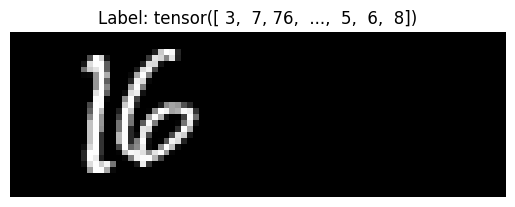

In [12]:
print(images[6].shape, labels[6])
image_tensor = images[6]
plt.imshow(image_tensor[0, 0:28, 0:84], cmap='gray')
plt.title(f"Label: {labels}")
plt.axis("off")
plt.show()

In [13]:
# Split into training and testing sets
tensors = dataset["images"].float() / 255.0 
labels = dataset["labels"]

X_train, X_test, y_train, y_test = train_test_split(tensors, labels, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"X_train shape: {X_train.shape}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Input features: {X_train.shape[1]}")
print(f"Classes: {len(np.unique(labels))}")

Training samples: 48960
X_train shape: torch.Size([48960, 1, 28, 84])
Testing samples: 12240
Input features: 1
Classes: 493


In [14]:
print(isinstance(X_train, torch.Tensor))
print(isinstance(y_train, torch.Tensor))
print(isinstance(X_test, torch.Tensor))
print(isinstance(y_test, torch.Tensor))

True
True
True
True


In [15]:
## Reshaping (flattening) so that we can perform matrix multiplication in the model
print(f"X_train shape before: {X_train.shape}")
print(f"X_test shape before: {X_test.shape}")

X_train = X_train.view(X_train.size(0), -1)
X_test = X_test.view(X_test.size(0), -1) 

print(f"X_train shape after: {X_train.shape}")
print(f"X_test shape after: {X_test.shape}")

X_train shape before: torch.Size([48960, 1, 28, 84])
X_test shape before: torch.Size([12240, 1, 28, 84])
X_train shape after: torch.Size([48960, 2352])
X_test shape after: torch.Size([12240, 2352])


In [16]:
# Define neural network using PyTorch
class NormalizedNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, debug=False):
        super().__init__()
        # Define layers: input -> hidden -> output
        self.hidden = nn.Linear(input_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.debug = debug

        # Normalization for ReLU
        nn.init.kaiming_normal_(self.hidden.weight, nonlinearity="relu")
        nn.init.zeros_(self.hidden.bias)

    def forward(self, x):
        """Forward pass through the network"""
        # Pass through hidden layer with sigmoid activation
        hidden_out = self.relu(self.hidden(x))
        # Adding a debug statement to check if the hidden layer is other than zero.
        if self.debug is True:
            print('forward pass')
            print(hidden_out.min().item(), hidden_out.max().item())
        # Pass through output layer with sigmoid activation
        output = self.output(hidden_out)
        return output

In [ ]:
## Creating a function make it easier to experiment with model parameters
def create_model_with_params(ModelClass, hidden_size, lr, debug=False):
    model = ModelClass(input_size=2352, hidden_size=hidden_size, output_size=1000, debug=debug)
    criterion = nn.CrossEntropyLoss()  
    optimizer = optim.SGD(model.parameters(), lr=lr)  # Stochastic Gradient Descent

    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
    print("Loss function: Cross-Entropy")
    print(f"Optimizer: SGD with learning rate {lr}")
    return model, criterion, optimizer

In [22]:
# Training loop with PyTorch
def train_batch_nn_model(model, criterion, optimizer, X_train, y_train, 
                   batch_size=64, num_epochs=1000, debug=True, return_loss=False):
    model.train()
    pytorch_loss_history = []

    print("Training with PyTorch autograd...")

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            # Forward pass: compute predictions
            predictions = model(X_batch)

            # Compute loss
            loss = criterion(predictions, y_batch)
            pytorch_loss_history.append(loss.item())

            # Backward pass: PyTorch automatically computes gradients!
            optimizer.zero_grad()  # Clear previous gradients
            loss.backward()  # Compute gradients (backpropagation)
            optimizer.step()  # Update weights using gradients

            epoch_loss += loss.item()

        # Print progress every 100 epochs
        if debug is True and (epoch + 1) % 100== 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

    print("\nTraining complete!")
    print(f"Final loss: {pytorch_loss_history[-1]:.4f}")

    if return_loss:
        return model, pytorch_loss_history

    return model

In [23]:
# Evaluate PyTorch model on test set
def evaluate_batch_model(model, X_test, y_test, batch_size=256):
    model.eval()  # Set model to evaluation mode

    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    correct = 0
    total = 0

    with torch.no_grad():  # turn off gradients for inference
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)          # shape: [num_samples, 10]
            predicted = torch.argmax(outputs, dim=1)  # get predicted class indices
            correct += (predicted == y_batch).sum().item()  # count correct predictions
            total += y_batch.size(0)  # divide by total samples

    accuracy = correct / total
    print(f"PyTorch Model Test Accuracy: {accuracy* 100:.2f}%")
    return accuracy

In [24]:
model, criterion, optimizer = create_model_with_params(NormalizedNet, 256, 0.04, debug=False)
model, loss_history = train_batch_nn_model(model, criterion, optimizer, X_train, y_train, batch_size=64, num_epochs=500, return_loss=True)
accuracy = evaluate_batch_model(model, X_test, y_test)


NormalizedNet(
  (hidden): Linear(in_features=2352, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

Total parameters: 604938
Loss function: Cross-Entropy
Optimizer: SGD with learning rate 0.04
Training with PyTorch autograd...


IndexError: Target 36 is out of bounds.